# 01b · 미니배치: 왜 데이터를 나누어 학습하나

**이번 질문:** 한 번 갱신할 때 데이터를 전부 써야 할까요? 일부만 쓰면 무엇을 얻고 무엇을 잃나요?

01번의 학습 루프는 스텝마다 5,000장 **전부**로 기울기를 계산했습니다. 실제 데이터는 6만 장, 수백만 장이고 모델도 훨씬 큽니다.
그래서 실제 학습은 데이터를 작은 묶음으로 나누어 묶음마다 한 번씩 갱신합니다. 이것이 미니배치이고, 뒤의 모든 학습 코드가 이 방식입니다.
왜 그래도 되는지(기울기의 평균이라는 구조), 무엇이 달라지는지(잡음과 속도), 어떻게 쓰는지(에폭·스텝·셔플)를 봅니다.

- 준비물: [01](01_gradients_and_learning.ipynb)의 학습 루프 네 줄, [00b](00b_vectorization.ipynb)의 정수 배열 인덱싱.
- 도착점: 미니배치 학습 루프를 직접 쓰고, 배치 크기가 잡음·속도·에폭당 진행에 미치는 영향을 설명합니다.
- 다음 연결: [04](04_optimizers.ipynb)의 optimizer는 모두 미니배치 기울기를 받습니다.

### 읽는 법

| 표시 | 뜻 | 어떻게 읽나 |
|---|---|---|
| 🔑 **핵심** | 수식·규칙·코드. 이 노트북이 가르치려는 것 | 남에게 설명할 수 있을 때까지 읽고, 코드를 가리고 다시 써 봅니다 |
| 🔍 **확인** | 검산 결과와 그림의 해석 | 실행해서 눈으로 보고 넘어갑니다. 외울 것은 없습니다 |
| 📎 **참고** | 배경 지식, 환경, 용어의 유래 | 처음 읽을 때는 건너뛰어도 됩니다 |
| ✏️ **연습** | 직접 바꿔 보는 문제 | 손으로 먼저 예상한 뒤 실행합니다 |

새 용어는 처음 나오는 자리에서 **용어** 상자로 한 줄씩 풀이합니다.

**이 노트북에서 반드시 가져갈 세 가지**

1. 전체 기울기는 표본 기울기의 **평균**입니다. 일부 표본만 평균낸 미니배치 기울기도 같은 값을 겨냥하는 추정치이고, 잡음의 크기는 $1/\sqrt{B}$로 줄어듭니다.
2. 한 스텝의 시간은 배치 크기에 비례합니다. 같은 시간에 작은 배치는 훨씬 많이 갱신하므로, 잡음이 있어도 초반 진행이 빠릅니다.
3. 에폭마다 순서를 섞어 $B$개씩 자르고, 스텝·에폭·처리한 표본 수를 구분해 기록합니다. 코드로는 `order = rng.permutation(N)` 뒤에 `for idx in batches: X[idx] ...`.

[전체 학습 경로](../../docs/CURRICULUM.md) · [글 규칙](../../docs/WRITING.md) · [그림 설계](../../docs/DESIGN.md) · [그림 보조 코드](../../src/utils/minibatch_plots.py)


In [1]:
# 준비 셀: 실행만 하고 넘어가도 됩니다.
# 1) 프로젝트 루트를 import 경로에 넣습니다. 노트북을 어느 폴더에서 열어도 src/를 찾기 위해서입니다.
import math                                            # math.ceil: 올림. 3절의 ⌈N/B⌉
import sys
import time                                            # time.perf_counter: 스텝 시간을 재는 정밀한 시계. 1절
from pathlib import Path

project_root = next(                                   # 현재 폴더부터 위로 올라가며
    p for p in (Path.cwd(), *Path.cwd().parents)       # src/utils/plotting.py가 있는 첫 폴더를 고릅니다
    if (p / "src" / "utils" / "plotting.py").is_file()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# 2) NumPy와 그림 설정. 배열 출력은 소수 4자리로 줄여 읽기 쉽게 합니다.
import numpy as np
from src.utils import setup_plots, run_check
setup_plots()
np.set_printoptions(precision=4, suppress=True)
print("NumPy", np.__version__, "· 준비 완료")

# 3) 데이터 로더와 이 노트북의 그림 함수(src/utils/minibatch_plots.py)
from src.data.mnist import load_mnist
from src.utils.minibatch_plots import (
    plot_step_cost, plot_batch_gradient_images, plot_batch_noise, plot_epoch_batches,
    plot_loss_vs_seen, plot_batch_size_effect,
)

NumPy 2.4.6 · 준비 완료


### 📎 이 노트북의 예시: MNIST 60,000장 전체

01번의 "7이면 1" 점수 회귀를 **학습 집합 60,000장 전체**로 합니다. 손실은 절반 MSE, 모델은 $z=x\cdot w+b$ 그대로입니다.
이미지가 많아야 "전부 쓰면 비싸다"는 문제가 실제로 보이기 때문입니다.

> **용어**
>
> - **미니배치(mini-batch)**: 한 번의 갱신에 쓰는 표본 묶음. 크기를 $B$라고 씁니다. 데이터 전부를 쓰면 full batch입니다.
> - **스텝(step)**: 파라미터를 한 번 갱신하는 단위. **에폭(epoch)**: 학습 데이터를 한 바퀴 다 쓰는 단위. 배치 크기가 $B$이면 한 에폭은 $\lceil N/B\rceil$ 스텝입니다.

아래 데이터 셀은 실행만 하고 넘어가도 됩니다. 배열 `X`는 60,000 × 784 실수라 약 376 MB입니다.

In [2]:
X, y, _, _ = load_mnist(download=True)     # (60000, 784) 이미지, (60000,) 정답 숫자. 시험용 두 값은 안 쓰므로 _ 로 버립니다
T = (y == 7).astype(float)                 # (60000,): 정답이 7이면 1.0, 아니면 0.0. True/False를 실수로 바꾼 것
N = len(X)                                 # 60000: 표본 수. 아래 모든 셀이 이 이름을 씁니다
print("X", X.shape, f"· {X.nbytes / 1e6:.0f} MB · 7의 비율 {T.mean():.3f}")

X (60000, 784) · 376 MB · 7의 비율 0.104


📎 **참고** · 아래 두 함수가 이 노트북 전체의 부품입니다. `full_loss`는 60,000장 **전체**의 손실이라 비싸서 진행을 기록할 때만 부르고,
`gradient_on`은 `idx`로 고른 표본들**만**의 기울기입니다. 식은 01번과 같고, 새 내용은 `X[idx]`, `T[idx]`로 일부 행만 고른다는 것뿐입니다(00b의 정수 배열 인덱싱).

In [3]:
def full_loss(w, b):
    """60,000장 전체의 절반 MSE: J = (1/2N) Σ_n (x_n·w + b − t_n)².
    w: (784,), b: 숫자 → 숫자 하나. 비싸므로 진행을 기록할 때만 씁니다."""
    return 0.5 * np.mean((X @ w + b - T) ** 2)


def gradient_on(idx, w, b):
    """idx로 고른 표본들만의 기울기. 01번의 dW = X.T @ dZ, db = dZ.sum()과 같은 식입니다 (dZ = residual / B).
    idx: (B,) 정수 배열, w: (784,), b: 숫자 → (dW: (784,), db: 숫자)."""
    residual = X[idx] @ w + b - T[idx]            # (B,): 배치의 예측 − 정답
    dW = X[idx].T @ residual / len(idx)           # (784,): 표본별 기울기 r_n·x_n 을 B개 평균한 것 = X_Bᵀ r / B
    db = residual.mean()                          # 편향의 기울기는 잔차의 평균
    return dW, db

## 🔑 1. 전체 배치의 비용: 한 스텝에 6만 장을 다 보면

**이 절에서 가져갈 것:** 한 스텝의 시간은 그 스텝에 쓰는 표본 수에 비례합니다. 60,000장으로 한 번 갱신할 시간에 64장으로는 수백 번 갱신할 수 있습니다.

01번의 기울기는 표본마다의 기울기를 **평균**낸 것이었습니다.

$$\nabla J(w)=\frac1N\sum_{n=1}^N\nabla\ell_n(w),\qquad \nabla\ell_n(w)=r_n\,x_n .$$

$N$이 커지면 이 합을 한 번 계산하는 데 드는 시간과 메모리가 $N$에 비례해 커집니다.
그런데 한 스텝은 파라미터를 **한 번** 움직일 뿐입니다. 6만 장을 다 봐서 방향을 아주 정확히 정하는 것과, 64장만 보고 대충 정하되 900번 움직이는 것 중 어느 쪽이 나을까요?
아래에서 먼저 시간을 잽니다.


In [4]:
# 쓰는 것: gradient_on (📎 함수 셀)
w0, b0 = np.zeros(784), 0.5                     # 시간만 재므로 아무 파라미터나 됩니다. 2절도 이 값에서 기울기를 봅니다
batch_sizes_cost = [8, 64, 512, 4096, 60000]    # 마지막 60000이 전체 배치
step_times = []
for B in batch_sizes_cost:
    idx = np.arange(B)                          # (B,): 앞에서 B장을 고르는 인덱스. 시간을 재는 데는 어느 B장이든 같습니다
    repeats = 3 if B >= 4096 else 100           # 큰 배치는 느려서 3번만, 작은 배치는 100번 재서 평균냅니다
    start = time.perf_counter()
    for _ in range(repeats):                    # 같은 계산을 repeats번 반복. 반복 변수는 안 쓰므로 _
        gradient_on(idx, w0, b0)
    step_times.append((time.perf_counter() - start) / repeats)   # 한 스텝의 평균 시간(초)
for B, t in zip(batch_sizes_cost, step_times):  # zip: 두 목록을 나란히 짝지어 돕니다
    print(f"B={B:6d}: 한 스텝 {t*1e3:8.3f} ms → 1초에 {1/t:8,.0f}번 갱신")
assert step_times[-1] > 50 * step_times[1], "60,000장 한 스텝은 64장 한 스텝보다 50배 넘게 느려야 합니다"

B=     8: 한 스텝    0.017 ms → 1초에   57,368번 갱신
B=    64: 한 스텝    0.039 ms → 1초에   25,521번 갱신
B=   512: 한 스텝    0.235 ms → 1초에    4,259번 갱신
B=  4096: 한 스텝    3.928 ms → 1초에      255번 갱신
B= 60000: 한 스텝   98.829 ms → 1초에       10번 갱신


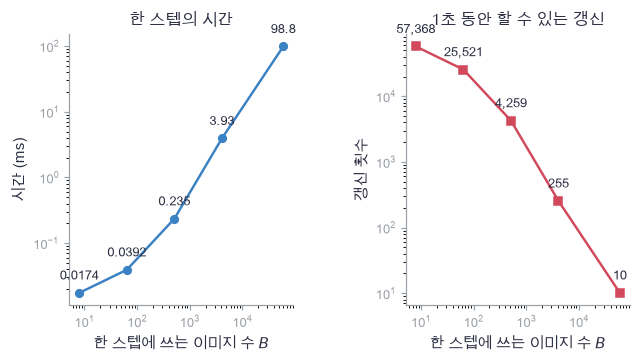

In [5]:
plot_step_cost(batch_sizes_cost, step_times)

🔍 **확인** · 오른쪽으로 갈수록 한 스텝이 비쌉니다. 왼쪽 끝에서 시간이 더 줄지 않는 것은 배열 연산의 고정 비용(00b 1절) 때문입니다.
같은 1초 동안 60,000장 배치는 수십 번, 64장 배치는 수만 번 갱신합니다. 이 차이를 쓰려면 "64장만 보고 계산한 기울기"가 믿을 만해야 합니다. 다음 절이 그 근거입니다.

📎 시간의 절대값은 컴퓨터마다 다릅니다. 신경망에서는 파라미터도 수백만 개라 배치 하나의 forward·backward가 훨씬 무겁고, 메모리 때문에 전체 배치는 아예 불가능한 경우가 많습니다.

### ✏️ 연습 1 · 스텝 시간은 표본 수에 비례

연습은 코딩 테스트처럼 **함수 뼈대가 미리 있고 핵심 한두 줄만 비어 있습니다.** `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓴 뒤, 셀을 실행하고 바로 아래 검사 셀을 실행하세요. 아직 채우지 않았으면 안내문만 나오고, 값이 다르면 "손계산과 다릅니다"가 나옵니다. 막히면 그 아래 "정답 보기"를 펼칩니다.

배치 `batch_size`장의 한 스텝에 `step_time`초가 걸렸다고 할 때, 비례 규칙으로 `new_batch_size`장의 한 스텝 시간 `new_step_time`과 그 시간으로 1초에 몇 번 갱신하는지 `updates_per_second`를 내는 두 줄을 채우세요. 시간의 절대값은 컴퓨터마다 다르므로 검사는 위 셀의 측정값이 아니라 둥근 가정 "64장에 0.5 ms"를 쓰고, 거기서 60,000장과 8장을 봅니다. 배열 연산의 고정 비용은 무시한 어림입니다.

In [6]:
def exercise_scale_step_time(batch_size, step_time, new_batch_size):
    """연습 1: 한 스텝의 시간은 표본 수에 비례. batch_size, new_batch_size: 정수, step_time: 초 → (new_step_time: 초, updates_per_second: 숫자)."""
    assert batch_size > 0 and new_batch_size > 0, "배치 크기는 1 이상이어야 합니다"
    assert step_time > 0, "잰 시간은 0보다 커야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: 표본 수에 비례해 늘리거나 줄인 new_step_time과, 그 시간으로 1초에 몇 번 갱신하는지 updates_per_second
    ### 힌트: batch_size장에 step_time초면 표본 하나에 step_time / batch_size초입니다. 1절 시간 셀의 print가 1/t로 "1초에 몇 번"을 냈습니다.
    raise NotImplementedError
    return new_step_time, updates_per_second

In [7]:
def check_scale_step_time(candidate):
    """64장에 0.5 ms가 걸렸다고 두고 60,000장과 8장의 시간을 손계산과 비교합니다. 통과하면 메시지를 출력합니다."""
    new_time, per_second = candidate(64, 0.5e-3, 60000)
    np.testing.assert_allclose(new_time, 0.46875)                   # 검산: 0.0005 × 60000 / 64 = 0.46875초
    np.testing.assert_allclose(per_second, 1 / 0.46875)             # 검산: 1초에 약 2.13번
    np.testing.assert_allclose(new_time / 0.5e-3, 937.5)            # 검산: 전체 배치 한 스텝 시간에 64장 스텝이 937.5번 = 60000/64
    small_time, small_per_second = candidate(64, 0.5e-3, 8)
    np.testing.assert_allclose(small_time, 6.25e-5)                 # 검산: 8장은 64장의 1/8 = 0.0000625초
    np.testing.assert_allclose(small_per_second, 16000.)            # 검산: 1초에 16,000번
    print("스텝 시간의 비례: 손계산과 일치합니다.")

run_check(check_scale_step_time, exercise_scale_step_time, hint="new_step_time = step_time * new_batch_size / batch_size, updates_per_second = 1 / new_step_time")

☐ exercise_scale_step_time: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: new_step_time = step_time * new_batch_size / batch_size, updates_per_second = 1 / new_step_time


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
new_step_time = step_time * new_batch_size / batch_size
updates_per_second = 1 / new_step_time
```

</details>

## 🔑 2. 미니배치 기울기는 전체 기울기의 추정치입니다

**이 절에서 가져갈 것:** $B$개만 뽑아 평균낸 기울기는 **기댓값이 전체 기울기와 같고**, 흔들림(표준편차)은 $1/\sqrt{B}$배입니다. 방향은 평균적으로 맞고, 잡음만 섞입니다.

> **용어**
>
> - **추정치(estimate)**: 전부를 계산하는 대신 일부로 어림한 값. 02번의 Monte Carlo 평균이 같은 구조입니다.
> - **표준편차 $\sigma/\sqrt{B}$**: 독립인 $B$개 값의 평균은 값 하나보다 $\sqrt{B}$배 덜 흔들립니다. 배치를 4배 키우면 잡음은 절반이 됩니다.

$$g_B=\frac1B\sum_{n\in\text{batch}}\nabla\ell_n,\qquad
\mathbb E[g_B]=\nabla J,\qquad \operatorname{Std}[g_B]=\frac{\sigma}{\sqrt B}.$$

01번처럼 기울기를 28×28 이미지로 보면 잡음이 무엇인지 눈에 보입니다. $w=0$, $b=0.5$에서 전체 기울기와 배치 기울기를 비교합니다.

> **코드**
>
> - `rng.integers(0, N, size=8)`: 0부터 N−1까지의 정수 8개를 무작위로 뽑습니다. 같은 번호가 두 번 나올 수 있는 **복원추출**입니다. 3절의 `permutation`(비복원)과 구분합니다.
> - `[식 for _ in range(3)]`: 같은 식을 3번 계산해 결과 3개를 목록으로 모읍니다. 반복 변수를 쓰지 않으므로 이름을 `_`로 둡니다.
> - `np.corrcoef(a, b)[0, 1]`: 두 벡터의 상관계수. 함수는 2×2 상관행렬을 돌려주므로 비대각 원소 `[0, 1]`을 꺼냅니다. 1이면 방향이 완전히 같고 0이면 무관합니다.

In [8]:
# 쓰는 것: gradient_on, N (📎 셀) · w0, b0 (1절)
grad_full, _ = gradient_on(np.arange(N), w0, b0)                # (784,): 인덱스 0…N−1 전부 = 60,000장 전체의 기울기. db는 안 쓰므로 _
rng_batch = np.random.default_rng(3)                            # 시드를 고정한 난수 생성기: 실행할 때마다 같은 배치가 뽑힙니다
grad_small = [gradient_on(rng_batch.integers(0, N, size=8), w0, b0)[0]     # 8장을 복원추출해 기울기 (784,)만 [0]으로 꺼내기
              for _ in range(3)]                                           # 를 3번 → 8장짜리 배치 기울기 3개
grad_large = [gradient_on(rng_batch.integers(0, N, size=64), w0, b0)[0]    # 같은 일을 64장으로
              for _ in range(3)]
print("전체 기울기와의 상관: 8장", [np.corrcoef(g, grad_full)[0, 1].round(2) for g in grad_small],
      "· 64장", [np.corrcoef(g, grad_full)[0, 1].round(2) for g in grad_large])


def to_image(g):
    """(784,) 기울기 벡터를 28×28 이미지로 접습니다 (00번 6절의 reshape). 아래 그림 셀에서 씁니다."""
    return g.reshape(28, 28)

전체 기울기와의 상관: 8장 [np.float64(0.91), np.float64(0.88), np.float64(0.9)] · 64장 [np.float64(0.98), np.float64(0.98), np.float64(0.98)]


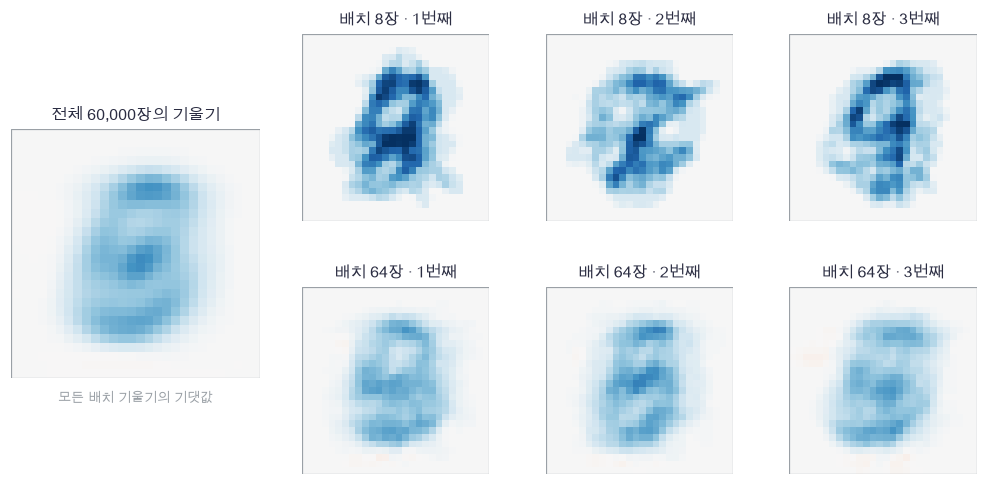

In [9]:
plot_batch_gradient_images(to_image(grad_full), [to_image(g) for g in grad_small], [to_image(g) for g in grad_large], 8, 64, N)

🔍 **확인** · 왼쪽이 60,000장 전체의 기울기 이미지입니다. 위 행은 8장짜리 배치라 어떤 숫자가 뽑혔는지 그대로 보이고, 아래 행은 64장짜리라 전체와 훨씬 비슷합니다.
어느 배치든 대체로 같은 방향(파랑은 파랑, 빨강은 빨강)이라 갱신을 반복하면 손실이 줄어듭니다. 아래에서 흔들림의 크기를 숫자로 확인합니다.

In [10]:
# 쓰는 것: X, T, gradient_on (📎 셀) · w0, b0 (1절). 계산량을 줄이려고 앞 5,000장만 씁니다
per_sample = (X[:5000] @ w0 + b0 - T[:5000])[:, None] * X[:5000]   # (5000, 784): 표본마다의 기울기 r_n·x_n. 잔차 (5000,)을 (5000, 1)로 세워 자기 행에 곱함
pixel = 400                                                        # 784개 좌표 중 하나(400번 화소)만 골라 그 기울기 값의 흔들림을 봅니다
batch_sizes_noise = np.array([1, 4, 16, 64, 256])
observed_std, expected_std = [], []
rng_noise = np.random.default_rng(40)
for B in batch_sizes_noise:
    picks = rng_noise.integers(0, 5000, size=(2000, B))            # (2000, B): 크기 B인 배치를 복원추출로 2,000개. 행 하나가 배치 하나
    batch_means = per_sample[picks, pixel].mean(axis=1)            # (2000,): 배치마다 400번 화소 기울기의 평균 = g_B의 한 좌표
    observed_std.append(batch_means.std())                         # 배치 2,000개 사이의 흔들림 (관측)
    expected_std.append(per_sample[:, pixel].std() / np.sqrt(B))   # 이론: 표본 하나의 표준편차 σ를 √B로 나눔
np.testing.assert_allclose(per_sample.mean(axis=0), gradient_on(np.arange(5000), w0, b0)[0])   # 검산: 표본별 기울기의 평균 = 그 5,000장의 기울기 (기댓값이 같다는 뜻)
print("관측 표준편차", np.round(observed_std, 4))
print("이론 σ/√B ", np.round(expected_std, 4))

관측 표준편차 [0.211  0.1074 0.0538 0.027  0.0131]
이론 σ/√B  [0.2137 0.1068 0.0534 0.0267 0.0134]


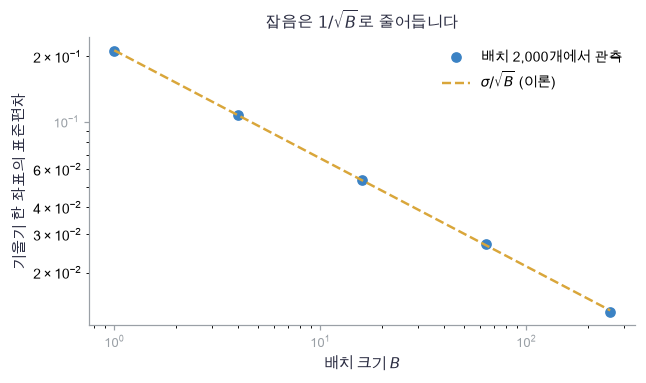

In [11]:
plot_batch_noise(batch_sizes_noise, observed_std, expected_std)

🔍 **확인** · 관측한 표준편차가 이론값 $\sigma/\sqrt{B}$를 따라 내려갑니다. 배치를 4배 키우면 잡음은 절반, 16배 키우면 1/4입니다.
반대로 말하면, 배치를 키워 잡음을 줄이는 효과는 갈수록 작아지는데 비용은 $B$에 비례해 커집니다. 여기서 "적당한 배치 크기"라는 절충이 나옵니다.

📎 이 실험은 같은 파라미터에서 배치만 바꾼 것입니다. 실제 학습은 스텝마다 파라미터가 바뀌므로, 한 에폭의 갱신은 전체 기울기로 한 번 갱신하는 것과 다릅니다.

### ✏️ 연습 2 · 배치 평균의 흔들림은 σ/√B

표본마다의 기울기 값 하나씩을 담은 `values` `(M,)`과, 배치마다 뽑힌 표본 번호를 행으로 둔 `picks` `(n_batches, B)`에서 배치마다의 평균 `batch_means` `(n_batches,)`와 이론 표준편차 `expected_std` $=\sigma/\sqrt{B}$를 내는 두 줄을 채우세요. 2절 잡음 실험이 400번 화소에 한 계산과 같습니다. 검사는 값 8개짜리 손계산으로 하고, 마지막에 배치 2,000개의 관측 흔들림이 이론값을 따르는지도 봅니다.

In [12]:
def exercise_batch_mean_noise(values, picks):
    """연습 2: 배치 평균의 흔들림. values: (M,) 표본별 기울기 값 하나씩, picks: (n_batches, B) 배치마다 뽑힌 표본 번호
    → (batch_means: (n_batches,), expected_std: 숫자 σ/√B)."""
    assert values.ndim == 1, "values는 (M,) 1차원 배열이어야 합니다"
    assert picks.ndim == 2, "picks는 (n_batches, B) 2차원 정수 배열이어야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: picks의 행마다 그 배치에 뽑힌 값들의 평균 batch_means (n_batches,)와, 표본 하나의 표준편차 values.std()를 √B로 나눈 expected_std
    ### 힌트: 2절 잡음 실험 셀의 batch_means·expected_std 두 줄과 같은 계산입니다. values[picks]는 (n_batches, B)이고 B는 picks.shape[1]입니다.
    raise NotImplementedError
    return batch_means, expected_std

In [13]:
def check_batch_mean_noise(candidate):
    """값 8개(평균 5, 표준편차 2)와 크기 2인 배치로 손계산과, 배치 2,000개의 관측 흔들림을 이론값과 비교합니다. 통과하면 메시지를 출력합니다."""
    example_values = np.array([2., 4., 4., 4., 5., 5., 7., 9.])   # (8,): 평균 5, 표준편차 2
    example_picks = np.array([[0, 7], [1, 2], [3, 6], [0, 0]])     # (4, 2): 배치 4개, 크기 B = 2. 복원추출이라 같은 번호가 두 번 올 수 있음
    batch_means, expected_std = candidate(example_values, example_picks)
    assert batch_means.shape == (4,), f"배치 평균은 배치마다 하나씩 (n_batches,) = (4,)이어야 하는데 {np.shape(batch_means)}입니다"
    np.testing.assert_allclose(batch_means, [5.5, 4., 5.5, 2.])   # 검산: 행마다 평균 [(2+9)/2, (4+4)/2, (4+7)/2, (2+2)/2]
    np.testing.assert_allclose(expected_std, 2 / np.sqrt(2))      # 검산: σ/√B = 2/√2 ≈ 1.4142
    full_means, full_std = candidate(example_values, np.arange(8)[None, :])   # (1, 8): 8개 전부를 한 배치로
    np.testing.assert_allclose(full_means, [5.])                  # 검산: B = M이면 배치 평균 = 전체 평균 5 (기댓값이 같다는 뜻)
    np.testing.assert_allclose(full_std, 2 / np.sqrt(8))          # 검산: 배치를 4배 키우면 흔들림은 절반
    many_picks = np.random.default_rng(0).integers(0, 8, size=(2000, 2))     # (2000, 2): 크기 2인 배치를 2,000개 뽑아 흔들림을 재기에 충분하게
    observed_std = candidate(example_values, many_picks)[0].std()            # 배치 2,000개 사이의 관측 표준편차
    np.testing.assert_allclose(observed_std, 2 / np.sqrt(2), rtol=0.05)      # 검산: 관측한 흔들림이 이론 σ/√B를 따름 (2절 그림과 같은 비교)
    print("배치 평균의 흔들림: 손계산과 일치합니다.")

run_check(check_batch_mean_noise, exercise_batch_mean_noise, hint="batch_means = values[picks].mean(axis=1), expected_std = values.std() / np.sqrt(picks.shape[1])")

☐ exercise_batch_mean_noise: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: batch_means = values[picks].mean(axis=1), expected_std = values.std() / np.sqrt(picks.shape[1])


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
batch_means = values[picks].mean(axis=1)
expected_std = values.std() / np.sqrt(picks.shape[1])
```

</details>

## 🔑 3. 에폭·스텝·셔플: 데이터를 어떻게 자르나

**이 절에서 가져갈 것:** 에폭마다 표본 순서를 섞고(`permutation`) 앞에서부터 $B$개씩 끊습니다. 마지막 배치는 작을 수 있고, 그 배치도 실제 크기로 평균냅니다.

> **용어**
>
> - **셔플(shuffle)**: 표본 순서를 무작위로 섞는 것. 같은 순서로 계속 학습하면 배치의 구성이 고정되어 잡음이 특정 방향으로 치우칩니다.
> - **비복원 순회**: 한 에폭 안에서는 각 표본을 정확히 한 번씩 씁니다. 2절의 복원추출(같은 표본이 여러 번)과 구분합니다.

$$\text{한 에폭의 스텝 수}=\left\lceil\frac NB\right\rceil,\qquad \text{마지막 배치 크기}=N-B\left(\left\lceil\frac NB\right\rceil-1\right).$$

> **코드**
>
> - `rng.permutation(size)`: 0부터 size−1까지를 무작위 순서로 늘어놓은 배열. 각 번호가 정확히 한 번씩 나옵니다(비복원).
> - `order[start:start + B]`(슬라이스): start번째부터 B개를 잘라 냅니다. 끝을 넘으면 있는 만큼만 나오므로 마지막 배치가 짧아집니다.
> - `range(0, size, B)`: 0, B, 2B, … 처럼 B씩 건너뛰며 시작 위치를 냅니다.
> - `math.ceil(N / B)`: 나눗셈을 올림한 정수. 수식의 $\lceil N/B\rceil$입니다.

In [14]:
def epoch_batches(size, batch_size, rng):
    """한 에폭의 배치 인덱스 목록: 0…size−1을 섞은 뒤 앞에서부터 batch_size개씩 끊습니다.
    size, batch_size: 정수, rng: 난수 생성기 → ⌈size/batch_size⌉개의 (B,) 정수 배열 목록. 마지막 것만 짧을 수 있습니다."""
    order = rng.permutation(size)                                  # (size,): 표본 번호를 무작위 순서로. 에폭마다 다시 섞입니다
    return [order[start:start + batch_size]                        # start부터 batch_size개 자르기
            for start in range(0, size, batch_size)]               # start = 0, B, 2B, …

In [15]:
# 쓰는 것: N (📎 데이터 셀)
rng_demo = np.random.default_rng(1)
demo_orders = [np.concatenate(epoch_batches(12, 4, rng_demo))     # 표본 12개를 4개씩 자른 배치들을 한 줄로 이어 붙임 (그림용)
               for _ in range(2)]                                  # 2에폭. 같은 rng를 이어 쓰므로 두 번째 에폭은 다른 순서
batches_60k = epoch_batches(N, 64, np.random.default_rng(0))       # 60,000장을 64개씩
assert len(batches_60k) == math.ceil(N / 64) == 938, "한 에폭의 스텝 수는 ⌈60000/64⌉ = 938이어야 합니다"
assert len(batches_60k[-1]) == N - 64 * 937, "마지막 배치는 나머지 60000 − 64·937 = 32장이어야 합니다"
assert np.array_equal(np.sort(np.concatenate(batches_60k)), np.arange(N)), "모든 표본이 정확히 한 번씩 나와야 합니다"   # 이어 붙여 정렬하면 0…N−1
print("60,000장을 64개씩:", len(batches_60k), "스텝 · 마지막 배치", len(batches_60k[-1]), "장")

60,000장을 64개씩: 938 스텝 · 마지막 배치 32 장


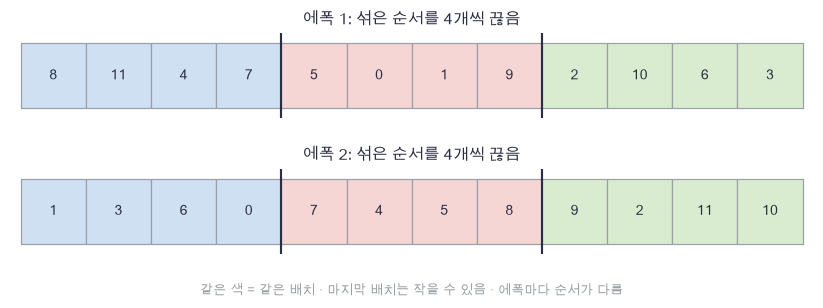

In [16]:
plot_epoch_batches(demo_orders, 4)

🔍 **확인** · 표본 12개를 두 에폭 동안 자른 모습입니다. 에폭마다 순서가 다르고, 같은 색이 같은 배치입니다.
60,000장을 64개씩 자르면 938스텝이고 마지막 배치는 32장입니다. 그 배치의 기울기도 32로 나누어 평균냅니다. `X[idx]`는 00b의 정수 배열 인덱싱입니다.

### ✏️ 연습 3 · 마지막 배치는 몇 장인가

표본 `size`개를 앞에서부터 `batch_size`개씩 끊었을 때 마지막 배치에 남는 표본 수 `last`를 내는 한 줄을 채우세요. 3절 수식의 마지막 배치 크기 $N-B(\lceil N/B\rceil-1)$이고, 딱 나눠떨어지면 `batch_size` 그대로입니다. 이 배치의 기울기도 이 수로 나누어 평균냅니다.

In [17]:
def exercise_last_batch_size(size, batch_size):
    """연습 3: 한 에폭의 마지막 배치 크기. size, batch_size: 정수 → 정수 (1 이상 batch_size 이하)."""
    assert size > 0 and batch_size > 0, "size와 batch_size는 1 이상이어야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: 앞에서부터 batch_size개씩 끊었을 때 마지막에 남는 표본 수 last (딱 나눠떨어지면 batch_size)
    ### 힌트: 3절 제목 셀의 두 번째 수식입니다. 올림은 준비 셀에서 import한 math로 합니다(3절 코드 상자).
    raise NotImplementedError
    return last

In [18]:
def check_last_batch_size(candidate):
    """나머지가 있는 경우 셋과 딱 나눠떨어지는 경우 하나를 손계산과, 표본 10개는 3절의 epoch_batches와 비교합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: epoch_batches (3절)
    assert candidate(60000, 64) == 32, "60000 − 64·937 = 32장이어야 합니다"
    assert candidate(10, 4) == 2, "10개를 4개씩 끊으면 [4, 4, 2]이므로 2여야 합니다"
    assert candidate(65, 16) == 1, "65 − 16·4 = 1이어야 합니다"
    assert candidate(64, 64) == 64, "딱 나눠떨어지면 마지막 배치도 꽉 찬 64여야 합니다 (0이 아닙니다)"
    assert candidate(10, 4) == len(epoch_batches(10, 4, np.random.default_rng(0))[-1]), "3절 epoch_batches의 마지막 배치 길이와 같아야 합니다"
    print("마지막 배치 크기: 손계산과 일치합니다.")

run_check(check_last_batch_size, exercise_last_batch_size, hint="last = size - batch_size * (math.ceil(size / batch_size) - 1)")

☐ exercise_last_batch_size: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: last = size - batch_size * (math.ceil(size / batch_size) - 1)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
last = size - batch_size * (math.ceil(size / batch_size) - 1)
```

</details>

## 🔑 4. 미니배치 학습 루프

**이 절에서 가져갈 것:** 01번의 네 줄(예측·손실·기울기·갱신)을 배치 인덱스 `idx` 위에서 돌립니다. 달라지는 것은 `X` 대신 `X[idx]`, `T` 대신 `T[idx]`뿐입니다.

```python
for epoch in range(epochs):
    for idx in epoch_batches(N, B, rng):          # 배치마다
        dW, db = gradient_on(idx, w, b)           # 이 배치의 기울기만
        w -= eta * dW; b -= eta * db              # 갱신
```

배치 손실은 스텝마다 흔들리므로, 진행을 보려면 가끔 **전체 손실**을 따로 잽니다. 가로축은 스텝 수가 아니라 **처리한 표본 수**로 둡니다. 배치 크기가 다른 실행을 같은 잣대로 비교하기 위해서입니다.

> **코드** · `history`는 진행 기록을 담는 사전(dict)입니다. `"seen"`·`"loss"`는 가끔 잰 전체 손실(가로축은 처리한 표본 수),
> `"batch_seen"`·`"batch_loss"`는 스텝마다의 배치 손실입니다. 마지막 줄의 `{key: np.array(value) for key, value in history.items()}`는
> 목록 넷을 그림에 쓰기 쉬운 배열로 바꾸는 사전 컴프리헨션입니다.

In [19]:
def train_minibatch(batch_size, learning_rate, epochs, seed=0, evaluations=20):
    """미니배치 SGD로 w, b를 학습합니다. 스텝마다 배치 B장으로 r = X[idx]·w + b − T[idx] (B,)를 구해
    w −= η·X[idx]ᵀr/B, b −= η·mean(r). 01번의 네 줄을 X[idx] 위에서 돌리는 것입니다.
    반환: w (784,), b, history(처리한 표본 수·전체 손실·스텝별 배치 손실). 전체 손실은 비싸서 evaluations번만 잽니다."""
    # 쓰는 것: X, T, N (📎 데이터 셀) · full_loss (📎 함수 셀) · epoch_batches (3절)
    rng = np.random.default_rng(seed)
    w, b = np.zeros(784), 0.0                                     # 01번처럼 0에서 시작
    steps_per_epoch = math.ceil(N / batch_size)                   # 마지막 짧은 배치까지 세므로 올림
    every = max(1, steps_per_epoch * epochs // evaluations)       # 전체 손실을 잴 스텝 간격. 전체 스텝 수를 evaluations로 나눔
    history = {"seen": [0], "loss": [full_loss(w, b)],            # 가끔 재는 전체 손실. 시작점(0장, 초기 손실)부터
               "batch_seen": [], "batch_loss": []}                # 스텝마다 재는 배치 손실
    seen, step = 0, 0                                             # 지금까지 처리한 표본 수, 갱신 횟수
    for epoch in range(epochs):
        for idx in epoch_batches(N, batch_size, rng):             # 배치마다. idx: 이번 배치의 표본 번호 (B,)
            residual = X[idx] @ w + b - T[idx]                    # 1. 예측과 잔차 (B,)
            history["batch_seen"].append(seen)                    # 2. 배치 손실 기록: 이 배치의 절반 MSE
            history["batch_loss"].append(0.5 * np.mean(residual ** 2))
            w -= learning_rate * X[idx].T @ residual / len(idx)   # 3+4. 배치 기울기(gradient_on과 같은 식)로 갱신
            b -= learning_rate * residual.mean()
            seen += len(idx)                                      # 마지막 배치는 len(idx)가 더 작습니다
            step += 1
            if step % every == 0:                                 # every 스텝마다 한 번씩만
                history["seen"].append(seen)
                history["loss"].append(full_loss(w, b))           # 60,000장 전체 손실
    return w, b, {key: np.array(value) for key, value in history.items()}   # 목록을 배열로 바꿔 돌려줍니다

In [20]:
# 쓰는 것: N, gradient_on, full_loss (📎 셀). 같은 표본 수(3에폭 = 180,000장)를 처리한 두 방식을 비교합니다
w_mb, b_mb, hist_mb = train_minibatch(batch_size=64, learning_rate=0.01, epochs=3)     # 미니배치: 938 × 3 = 2,814스텝

w_full, b_full = np.zeros(784), 0.0                                  # 전체 배치: 에폭마다 한 스텝, 모두 3스텝
full_seen, full_losses = [0], [full_loss(w_full, b_full)]            # 처리한 표본 수와 그때의 전체 손실. 시작점 포함
for epoch in range(3):
    dW, db = gradient_on(np.arange(N), w_full, b_full)               # 60,000장 전체의 기울기
    w_full -= 0.03 * dW                                              # 학습률은 미니배치의 3배(0.03). 세 걸음뿐이라 걸음을 키워 줘도
    b_full -= 0.03 * db                                              #   아래 검산처럼 미니배치가 앞섭니다
    full_seen.append(N * (epoch + 1))
    full_losses.append(full_loss(w_full, b_full))
assert hist_mb["loss"][-1] < full_losses[-1] / 2, "같은 180,000장을 처리했을 때 미니배치의 전체 손실이 전체 배치의 절반 아래여야 합니다"
print(f"3에폭(180,000장 처리) 뒤 전체 손실: 미니배치 64 → {hist_mb['loss'][-1]:.4f} · 전체 배치 3스텝 → {full_losses[-1]:.4f}")

3에폭(180,000장 처리) 뒤 전체 손실: 미니배치 64 → 0.0179 · 전체 배치 3스텝 → 0.0389


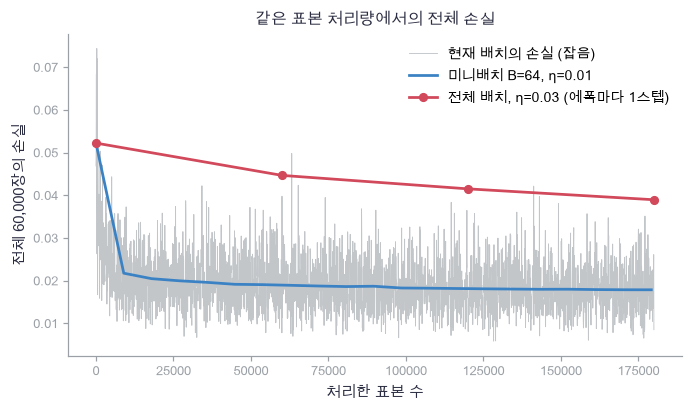

In [21]:
plot_loss_vs_seen({"미니배치 B=64, η=0.01": (hist_mb["seen"], hist_mb["loss"]), "전체 배치, η=0.03 (에폭마다 1스텝)": (full_seen, full_losses)},
                  batch_trace=(hist_mb["batch_seen"], hist_mb["batch_loss"]))

🔍 **확인** · 같은 180,000장을 처리했는데, 전체 배치는 세 번만 움직여 손실이 조금 줄었고 미니배치는 2,814번 움직여 훨씬 더 내려갔습니다.
회색 선은 스텝마다의 배치 손실입니다. 잡음이 크지만 추세는 전체 손실과 같습니다. **정확한 방향으로 세 걸음보다 대충 맞는 방향으로 수천 걸음이 멀리 갑니다.**

### ✏️ 연습 4 · 한 에폭 동안 배치마다 갱신

3절 `epoch_batches`가 내주는 배치를 돌며 파라미터를 갱신하는 **한 에폭**을 완성하세요. 반복문 머리와 사본 만들기는 써 두었으니, 반복문 안의 세 줄(이 배치의 기울기 `dW`, `db`를 `gradient_fn`으로 구하고 `eta`만큼 내려가기)을 채웁니다. 기울기 계산은 인자로 받은 `gradient_fn(idx, w, b)`에 맡기므로, 이 연습에서 볼 것은 **배치마다 갱신하고 그 결과를 다음 배치가 이어 쓴다**는 루프 자체입니다. 검사는 손계산용 기울기 두 개와, MNIST 한 에폭을 4절 `train_minibatch`와 비교합니다.

In [22]:
def exercise_epoch_update(gradient_fn, size, batch_size, w, b, eta, rng):
    """연습 4: 한 에폭 동안 배치마다 갱신. gradient_fn(idx, w, b) → (dW: (D,), db: 숫자), size, batch_size: 정수,
    w: (D,), b: 숫자, eta: 학습률, rng: 난수 생성기 → 에폭이 끝난 (w_new: (D,), b_new: 숫자)."""
    assert batch_size > 0, "batch_size는 1 이상이어야 합니다"
    w_new, b_new = w.copy(), b                             # 인자로 받은 w는 건드리지 않고 사본을 갱신합니다
    for idx in epoch_batches(size, batch_size, rng):       # 3절의 배치 목록. idx: 이번 배치의 표본 번호 (B,)
        ### 이 주석 아래에 다음을 구현하세요.
        ### 구현할 내용: 지금의 w_new, b_new에서 이 배치의 기울기를 gradient_fn으로 구하고 eta만큼 내려가는 세 줄
        ### 힌트: 4절 제목 셀의 코드 상자 세 줄(기울기 한 줄 + 갱신 두 줄)입니다. w_new는 사본이라 제자리 갱신(-=)을 써도 됩니다.
        raise NotImplementedError
    return w_new, b_new

In [23]:
def check_epoch_update(candidate):
    """배치 크기에만 반응하는 기울기와 w에 반응하는 기울기로 손계산과, MNIST 한 에폭은 4절 train_minibatch와 비교합니다."""
    # 쓰는 것: gradient_on (📎 함수 셀) · N (📎 데이터 셀) · train_minibatch (4절)
    def size_gradient(idx, w_now, b_now):
        """검사용 기울기: 배치 크기만큼 큰 dW와 언제나 1인 db. 배치를 모두 돌았는지 합으로 확인하기 위한 것입니다."""
        return np.ones(2) * len(idx), 1.0

    w_new, b_new = candidate(size_gradient, 10, 4, np.zeros(2), 0.0, 0.1, np.random.default_rng(0))
    assert w_new.shape == (2,), f"w_new의 모양은 (D,) = (2,)여야 하는데 {np.shape(w_new)}입니다"
    np.testing.assert_allclose(w_new, [-1., -1.])   # 검산: 배치 [4, 4, 2]의 dW 합이 10 → 0 − 0.1 × 10
    np.testing.assert_allclose(b_new, -0.3)         # 검산: 스텝 3번 × db 1 → 0 − 0.1 × 3 (마지막 짧은 배치도 한 스텝)

    def w_gradient(idx, w_now, b_now):
        """검사용 기울기: 지금의 w_now를 그대로 dW로 돌려줍니다. 갱신된 w를 다음 스텝에 쓰는지 보기 위한 것입니다."""
        return w_now.copy(), 0.0

    start_w = np.array([1., 1.])
    decayed, _ = candidate(w_gradient, 4, 2, start_w, 0.0, 0.5, np.random.default_rng(0))
    np.testing.assert_allclose(decayed, [0.25, 0.25])       # 검산: 스텝마다 w가 절반 → 2스텝 뒤 (1/2)² = 0.25
    np.testing.assert_array_equal(start_w, [1., 1.])        # 검산: 인자로 준 w는 그대로여야 함
    w_ref, b_ref = candidate(gradient_on, N, 4096, np.zeros(784), 0.0, 0.01, np.random.default_rng(0))
    w_book, b_book, _ = train_minibatch(batch_size=4096, learning_rate=0.01, epochs=1, evaluations=1)
    np.testing.assert_allclose(w_ref, w_book)               # 검산: 4절 train_minibatch의 1에폭과 같음 (같은 시드 = 같은 배치 순서)
    np.testing.assert_allclose(b_ref, b_book)               # 검산: 편향도 같음
    print("한 에폭 갱신: 손계산과 일치합니다.")

run_check(check_epoch_update, exercise_epoch_update, hint="dW, db = gradient_fn(idx, w_new, b_new) 뒤에 w_new -= eta * dW, b_new -= eta * db")

☐ exercise_epoch_update: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: dW, db = gradient_fn(idx, w_new, b_new) 뒤에 w_new -= eta * dW, b_new -= eta * db


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
dW, db = gradient_fn(idx, w_new, b_new)
w_new -= eta * dW
b_new -= eta * db
```

</details>

## 🔑 5. 배치 크기가 바꾸는 것: 잡음, 시간, 에폭당 진행

**이 절에서 가져갈 것:** 배치가 작을수록 에폭당 갱신이 많아 진행이 빠르지만 잡음이 크고 벡터화 이득을 잃습니다. 배치가 클수록 매끄럽고 한 스텝이 효율적이지만 에폭당 갱신이 적습니다.

같은 학습률 $\eta=0.01$, 같은 한 에폭에서 배치 크기만 8, 64, 512, 4096으로 바꿉니다.


In [24]:
# 쓰는 것: train_minibatch (4절). 학습률 0.01, 1에폭은 같고 배치 크기만 바꿉니다
batch_sizes_effect = [8, 64, 512, 4096]
effect_curves, effect_times, effect_images = {}, [], []              # 배치 크기별 손실 곡선, 한 에폭의 시간, 학습된 w 이미지
for B in batch_sizes_effect:
    start = time.perf_counter()
    w_B, b_B, hist_B = train_minibatch(batch_size=B, learning_rate=0.01, epochs=1, evaluations=12)
    effect_times.append(time.perf_counter() - start)                 # 한 에폭에 걸린 시간. 전체 손실 12번 평가 포함
    effect_curves[B] = (hist_B["seen"], hist_B["loss"])              # 가로축: 처리한 표본 수, 세로축: 전체 손실
    effect_images.append(w_B.reshape(28, 28))                        # 학습된 가중치를 이미지로
    print(f"B={B:5d}: 한 에폭 뒤 손실 {hist_B['loss'][-1]:.4f} · {len(hist_B['batch_loss'])} 스텝 · {effect_times[-1]:.2f}초")

B=    8: 한 에폭 뒤 손실 0.0178 · 7500 스텝 · 0.27초
B=   64: 한 에폭 뒤 손실 0.0188 · 938 스텝 · 0.18초


B=  512: 한 에폭 뒤 손실 0.0221 · 118 스텝 · 0.22초


B= 4096: 한 에폭 뒤 손실 0.0352 · 15 스텝 · 0.24초


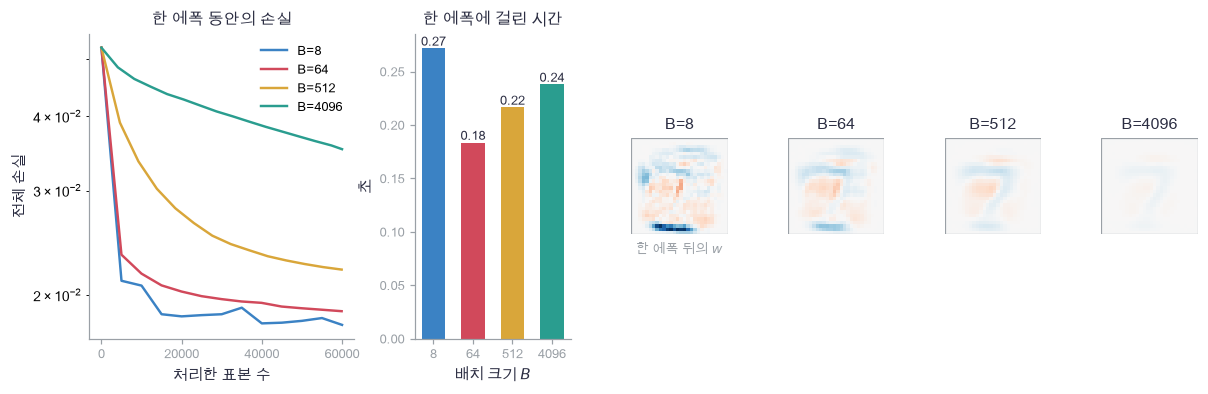

In [25]:
plot_batch_size_effect(effect_curves, effect_times, effect_images, batch_sizes_effect)

🔍 **확인** · 작은 배치는 같은 표본 수에서 손실이 빨리 내려갑니다. 갱신 횟수가 많기 때문입니다. 대신 곡선이 흔들리고, 스텝 수가 많아 한 에폭의 시간이 오히려 깁니다(배열 연산 고정 비용).
큰 배치는 한 에폭에 몇 번 못 움직여 손실이 덜 내려갑니다. 오른쪽의 가중치 이미지도 B가 작을수록 더 진하게 자랐습니다.
실무에서 32에서 256 사이를 흔히 쓰는 이유가 이 절충입니다. GPU에서는 큰 배치의 한 스텝이 더 싸져 절충점이 오른쪽으로 옮겨 갑니다.

📎 시간 측정에는 전체 손실 평가(60,000장, 12번)도 포함되어 있습니다. 순수 학습 시간은 그보다 짧습니다.

### ✏️ 연습 5 · 작은 배치의 에폭이 더 긴 이유

위 실험에서 배치 8의 한 에폭이 배치 4096보다 오래 걸렸습니다. 그 이유를 숫자로 확인합니다. 스텝 하나에 **고정 비용** `fixed_cost`와 **표본마다의 비용** `sample_cost`가 든다고 두고, 스텝 하나의 시간 `step_time`과 한 에폭 전체의 시간 `epoch_time`을 내는 두 줄을 채우세요(스텝 수 `steps`는 3절 식으로 써 두었습니다). 검사는 배치가 작을 때 한 스텝은 싸지만 한 에폭은 길어지는 것을 봅니다.

In [26]:
def exercise_epoch_time(size, batch_size, fixed_cost, sample_cost):
    """연습 5: 배치 크기에 따른 한 에폭의 시간. size, batch_size: 정수, fixed_cost: 스텝 하나의 고정 비용(초),
    sample_cost: 표본 하나당 비용(초) → (step_time: 초, epoch_time: 초)."""
    assert size > 0 and batch_size > 0, "size와 batch_size는 1 이상이어야 합니다"
    assert fixed_cost >= 0 and sample_cost >= 0, "비용은 0 이상이어야 합니다"
    steps = math.ceil(size / batch_size)                   # 3절의 에폭당 스텝 수 ⌈N/B⌉
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: 스텝 하나의 시간 step_time(고정 비용 + 표본마다의 비용)과, 한 에폭 전체의 시간 epoch_time
    ### 힌트: 1절 🔍 확인의 "배열 연산의 고정 비용"이 fixed_cost이고, 표본 수에 비례하는 부분이 sample_cost입니다. 에폭 시간은 스텝 하나의 시간을 steps배 한 것입니다.
    raise NotImplementedError
    return step_time, epoch_time

In [27]:
def check_epoch_time(candidate):
    """표본 6,000개에 고정 비용 0.1 ms, 표본당 1 µs를 두고 배치 8과 600의 한 에폭을 손계산과 비교합니다. 통과하면 메시지를 출력합니다."""
    small_step, small_epoch = candidate(6000, 8, 1e-4, 1e-6)
    np.testing.assert_allclose(small_step, 1.08e-4)         # 검산: 0.0001 + 8 × 0.000001 = 0.000108초
    np.testing.assert_allclose(small_epoch, 0.081)          # 검산: 750스텝 × 0.000108 = 0.081초
    large_step, large_epoch = candidate(6000, 600, 1e-4, 1e-6)
    np.testing.assert_allclose(large_step, 7e-4)            # 검산: 0.0001 + 600 × 0.000001 = 0.0007초. 한 스텝은 6.5배 비싸지만
    np.testing.assert_allclose(large_epoch, 0.007)          # 검산: 10스텝 × 0.0007 = 0.007초. 한 에폭은 오히려 11.6배 빠름
    assert small_epoch > 10 * large_epoch, "고정 비용이 있으면 작은 배치의 한 에폭이 훨씬 길어야 합니다 (5절 확인)"
    free_small = candidate(6000, 8, 0.0, 1e-6)[1]
    free_large = candidate(6000, 600, 0.0, 1e-6)[1]
    np.testing.assert_allclose(free_small, free_large)      # 검산: 고정 비용이 0이면 에폭 시간은 배치 크기와 무관한 6000 × 0.000001 = 0.006초
    print("한 에폭의 시간: 손계산과 일치합니다.")

run_check(check_epoch_time, exercise_epoch_time, hint="step_time = fixed_cost + sample_cost * batch_size, epoch_time = steps * step_time")

☐ exercise_epoch_time: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: step_time = fixed_cost + sample_cost * batch_size, epoch_time = steps * step_time


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
step_time = fixed_cost + sample_cost * batch_size
epoch_time = steps * step_time
```

</details>

## 📎 6. 배치 크기와 학습률

배치를 키우면 기울기의 잡음이 줄어 더 큰 학습률을 견딥니다. 실무에서는 "배치를 $k$배 키우면 학습률도 $k$배"라는 경험칙(linear scaling)을 출발점으로 쓰되, 반드시 실험으로 확인합니다.
반대로 배치 1(순수 SGD)에서는 위 실험의 $\eta=0.01$도 위험할 수 있습니다. 04번에서 학습률과 곡률의 관계($\eta<2/a$)를 보고, Momentum·Adam이 잡음 섞인 기울기를 어떻게 다루는지 봅니다.

미니배치의 잡음은 나쁘기만 한 것이 아닙니다. 평평한 최솟값을 선호하게 하고 좁은 골짜기에서 빠져나오게 한다는 관찰이 있지만, 이 노트북의 선형 회귀에서는 그 효과를 보이지 않습니다.

## ✏️ 7. 직접 채워서 확인합니다

연습은 코딩 테스트처럼 **함수 뼈대가 미리 있고 핵심 한두 줄만 비어 있습니다.**
`raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓴 뒤, 셀을 실행하고 바로 아래 검사 셀을 실행하세요.
아직 채우지 않았으면 안내문만 나오고, 값이 다르면 "손계산과 다릅니다"가 나옵니다. 막히면 그 아래 "정답 보기"를 펼칩니다.

### 연습 A · 한 에폭의 배치 만들기 (3절)

표본 `size`개를 섞어 `batch_size`개씩 끊은 인덱스 배열의 목록을 돌려줍니다. 섞는 줄과 끊는 줄을 채우세요.

In [28]:
def exercise_epoch_batches(size, batch_size, rng):
    """연습 A: 한 에폭의 배치 목록. size, batch_size: 정수, rng: 난수 생성기 → (B,) 정수 배열의 목록."""
    assert batch_size > 0, "batch_size는 1 이상이어야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: order = 0…size−1 을 섞은 배열, batches = order를 앞에서부터 batch_size개씩 자른 목록
    ### 힌트: rng.permutation(size), [order[s:s + batch_size] for s in range(0, size, batch_size)]
    raise NotImplementedError
    return batches

In [29]:
def check_epoch_batches(candidate):
    """표본 10개, 배치 4개로 크기·빠짐·섞임을 검사합니다. 통과하면 메시지를 출력합니다."""
    batches = candidate(10, 4, np.random.default_rng(0))
    assert [len(b) for b in batches] == [4, 4, 2], "배치 크기는 [4, 4, 2]여야 합니다 (마지막 배치는 2개)"
    np.testing.assert_array_equal(np.sort(np.concatenate(batches)), np.arange(10))   # 검산: 빠짐·중복 없음
    again = candidate(10, 4, np.random.default_rng(1))
    assert not np.array_equal(np.concatenate(batches), np.concatenate(again)), "다른 시드는 다른 순서를 내야 합니다 (섞는 줄을 확인)"
    print("에폭 배치: 크기·빠짐 없음·섞임 모두 맞습니다.")

run_check(check_epoch_batches, exercise_epoch_batches, hint="order = rng.permutation(size); batches = [order[s:s + batch_size] for s in range(0, size, batch_size)]")

☐ exercise_epoch_batches: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: order = rng.permutation(size); batches = [order[s:s + batch_size] for s in range(0, size, batch_size)]


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
order = rng.permutation(size)
batches = [order[s:s + batch_size] for s in range(0, size, batch_size)]
```

</details>

### ✏️ 연습 B · 배치 하나의 기울기 (2절)

인덱스 `idx`로 고른 표본들만으로 잔차와 가중치 기울기를 만드는 두 줄을 채우세요. 배치 크기로 평균냅니다.

In [30]:
def exercise_batch_gradient(X_data, T_data, w, b, idx):
    """연습 B: 배치 하나의 기울기. X_data: (N, 784), T_data: (N,), w: (784,), b: 숫자, idx: (B,) → (dW: (784,), db: 숫자)."""
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: residual = 배치의 예측 − 정답 (B,), dW = 배치 이미지의 전치 @ residual / B (784,)
    ### 힌트: X_data[idx], T_data[idx] 만 씁니다. len(idx)가 B입니다.
    raise NotImplementedError
    return dW, residual.mean()

In [31]:
def check_batch_gradient(candidate):
    """앞 5,000장짜리 배치와 표본 하나짜리 배치로 본문의 gradient_on과 비교합니다."""
    # 쓰는 것: X, T, gradient_on (📎 셀) · w0, b0 (1절)
    idx = np.arange(5000)
    dW, db = candidate(X, T, w0, b0, idx)
    ref_dW, ref_db = gradient_on(idx, w0, b0)
    np.testing.assert_allclose(dW, ref_dW)          # 검산: 가중치 기울기 = 본문
    np.testing.assert_allclose(db, ref_db)          # 검산: 편향 기울기 = 본문
    small_dW, _ = candidate(X, T, w0, b0, np.array([7, 7]))                # 같은 표본을 두 번 담은 배치 = 그 표본 하나의 기울기
    np.testing.assert_allclose(small_dW, (X[7] @ w0 + b0 - T[7]) * X[7])   # 검산: r_7 · x_7
    print("배치 기울기: 본문의 gradient_on과 일치합니다.")

run_check(check_batch_gradient, exercise_batch_gradient, hint="residual = X_data[idx] @ w + b - T_data[idx]; dW = X_data[idx].T @ residual / len(idx)")

☐ exercise_batch_gradient: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: residual = X_data[idx] @ w + b - T_data[idx]; dW = X_data[idx].T @ residual / len(idx)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
residual = X_data[idx] @ w + b - T_data[idx]
dW = X_data[idx].T @ residual / len(idx)
```

</details>

### ✏️ 연습 C · 에폭당 스텝 수와 처리한 표본 수 (3절)

표본 `size`개, 배치 `batch_size`일 때 한 에폭의 스텝 수(올림)를 돌려주는 한 줄을 채우세요.

In [32]:
def exercise_steps_per_epoch(size, batch_size):
    """연습 C: 한 에폭의 스텝 수. size, batch_size: 정수 → 정수."""
    assert size > 0 and batch_size > 0, "size와 batch_size는 1 이상이어야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: size / batch_size 를 올림한 정수
    ### 힌트: math.ceil(size / batch_size) 또는 int(np.ceil(size / batch_size))
    raise NotImplementedError
    return steps

In [33]:
def check_steps(candidate):
    """올림이 맞는지 세 경우(나머지 있음 둘, 딱 나눠떨어짐 하나)와 3절의 함수로 검사합니다."""
    # 쓰는 것: epoch_batches (3절)
    assert candidate(60000, 64) == 938, "60000/64 = 937.5 → 올림 938"
    assert candidate(65, 16) == 5, "65/16 = 4.06 → 올림 5"
    assert candidate(64, 64) == 1, "딱 나눠떨어지면 그대로 1"
    assert candidate(10, 4) == len(epoch_batches(10, 4, np.random.default_rng(0))), "3절 epoch_batches의 배치 수와 같아야 합니다"
    print("스텝 수: 올림이 맞습니다.")

run_check(check_steps, exercise_steps_per_epoch, hint="steps = math.ceil(size / batch_size)")

☐ exercise_steps_per_epoch: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: steps = math.ceil(size / batch_size)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
steps = math.ceil(size / batch_size)
```

</details>

### ✏️ 준비도 질문 · 다음 노트북으로 갈 준비

🔑 표시가 붙은 절의 내용만으로 답할 수 있어야 합니다.

1. 미니배치 기울기가 전체 기울기의 "추정치"라는 말을 기댓값과 표준편차로 설명할 수 있나요?
2. 배치를 16에서 256으로 키우면 잡음은 몇 배로 줄고, 한 에폭의 스텝 수는 몇 배로 줄어드나요?
3. 스텝·에폭·처리한 표본 수 셋을 구분하고, 배치 크기가 다른 실행을 어느 축으로 비교할지 말할 수 있나요?
4. 01번의 학습 루프를 미니배치 루프로 바꿀 때 달라지는 줄이 무엇인지 말할 수 있나요?

**다음:** [02 · 확률에서 손실 만들기](02_probability_and_losses.ipynb). 04번의 optimizer는 이 노트북의 배치 기울기를 받습니다.